In [4]:
import pandas as pd

In [5]:
district = 'Kushtia'
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'UV']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,UV
12054,1,1,2013,7.0
12055,2,1,2013,7.0
12056,3,1,2013,4.0
12057,4,1,2013,6.0
12058,5,1,2013,6.0


Date range: 2014-01-01 to 2024-12-31


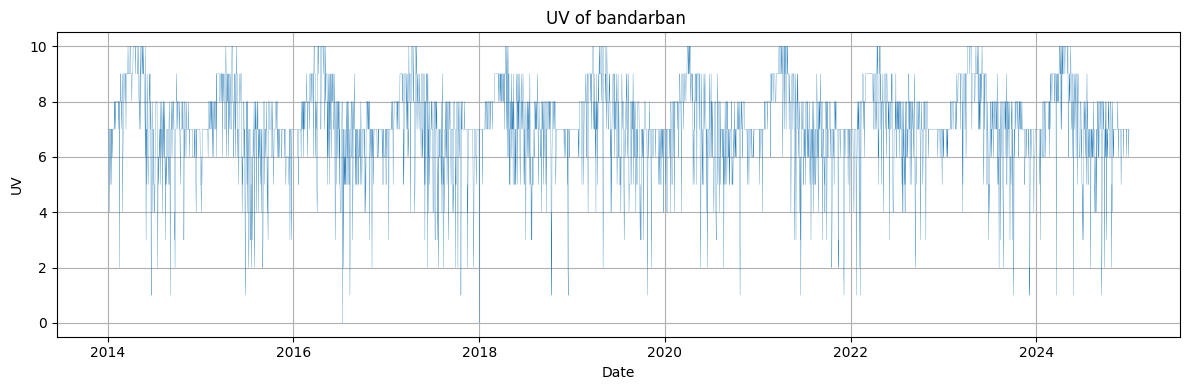

In [6]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")


# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['UV'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('UV')
plt.title('UV of bandarban ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['UV'].resample('MS').mean().reset_index()
df_monthly = df_monthly.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['UV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


# RF

In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Dew-Point Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2', n_jobs=-1)

print("\n=== 5-Fold CV R² (with Fourier) ===")
print(f"Mean : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores: {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Dew-Point Prediction (Test) ===
R²          : 0.8229
RMSE        : 0.391 °C
MSE         : 0.1529
Accuracy (± tolerance):
  ±0.5 °C :  0.81%
  ±1.0 °C :  1.00%
  ±2.0 °C :  1.00%
  ±3.0 °C :  1.00%

=== 5-Fold CV R² (with Fourier) ===
Mean : 0.7825  (±0.0229)
Scores: [0.823  0.7593 0.7738 0.7654 0.7908]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.694312
year_val    0.114470
   cos_1    0.049947
   sin_2    0.049062
   cos_3    0.047025
   sin_3    0.039332
   cos_2    0.005853


# XGBoost 

In [10]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

# --- 4) Train MultiOutput XGBoost ---
xgb_model = xgb.XGBRegressor( 
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:.2f}%")

# --- 6) 5-fold CV R^2 ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(xgb_model, X, y, cv=cv, scoring="r2", n_jobs=-1)
print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {cv_r2.mean():.4f}  |  Std : {cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.7996
xgboost_MSE  : 0.1730
xgboost_RMSE : 0.4160
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 74.07%
  ±1.0°C : 100.00%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.7711  |  Std : 0.0162

==== Top Feature Importances ====
 feature  importance
   sin_1    0.551876
   sin_2    0.314311
   cos_1    0.088877
year_val    0.018649
   cos_3    0.009542
   sin_3    0.009451
   cos_2    0.007293


# light gbm

In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:.2f}%")

# --- 6) 5-fold CV R^2 ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(lgb_model, X, y, cv=cv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {cv_r2.mean():.4f}  |  Std : {cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 7
[LightGBM] [Info] Start training from score 7.166332
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

# cat boost

In [12]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,           # Regularization is your friend with 4k rows
        bootstrap_type='Bayesian',
        bagging_temperature=1,
        random_strength=1,
        loss_function='RMSE',    # Or 'Huber' if you want it to match your LSTM
        random_seed=42,
        verbose=0
    )


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:.2f}%")

# --- 6) 5-fold CV R^2 ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(cat_model, X, y, cv=cv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {cv_r2.mean():.4f}  |  Std : {cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.8424
CatBoost_MSE  : 0.1361
CatBoost_RMSE : 0.3689
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 81.48%
  ±1.0°C : 96.30%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.7842  |  Std : 0.0287

==== Top Feature Importances ====
 feature  importance
   sin_1   45.690547
year_val   11.061861
   cos_1   10.139221
   sin_2    9.497939
   cos_2    8.893286
   sin_3    8.782768
   cos_3    5.934380


# comparision

In [13]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.822912 0.152930 0.391063       81.481481      100.000000           100.0           100.0
      XGBoost 0.799619 0.173045 0.415987       74.074074      100.000000           100.0           100.0
     LightGBM 0.829659 0.147103 0.383540       81.481481      100.000000           100.0           100.0
     CatBoost 0.842412 0.136090 0.368904       81.481481       96.296296           100.0           100.0


In [14]:
def select_best_model(df, sort_by_metrics):
    """
    Ranks models based on a list of metrics (in order of priority) 
    and returns the best model name.

    Args:
        df (pd.DataFrame): The model performance DataFrame.
        sort_by_metrics (list of tuples): A list where each tuple is 
            (metric_name, maximize_boolean). 
            True=Higher is better (e.g., R^2, Accuracy).
            False=Lower is better (e.g., MSE, RMSE).
    
    Returns:
        str: The name of the best performing model.
    """
    
    sort_cols = [metric[0] for metric in sort_by_metrics]
    # If maximize=True, we use ascending=False (for descending order).
    # If maximize=False, we use ascending=True (for ascending order).
    ascending_list = [not metric[1] for metric in sort_by_metrics]

    # Rank the models using multiple columns for tie-breaking
    ranked_df = df.sort_values(
        by=sort_cols, 
        ascending=ascending_list
    ).reset_index(drop=True)
    
    best_model_name = ranked_df.iloc[0]['Model']
    
    print("\n--- Model Ranking Based on Current Strategy ---")
    # Show only the Model column and the metrics used for ranking
    print(ranked_df[['Model'] + sort_cols].to_string(index=False))
    
    return best_model_name


MODEL_NAMES = ["Random Forest", "XGBoost", "LightGBM"]
R_SQUARED_VALUES = [rf_r2_f, xgboost_r2_f, lgb_r2_f]
MSE_VALUES = [rf_mse_f, xgboost_mse_f, lgb_mse_f]
RMSE_VALUES = [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f]
ACC_0_5_VALUES = [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100]
ACC_1_0_VALUES = [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100]
ACC_2_0_VALUES = [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100]
ACC_3_0_VALUES = [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100]


# You can add more metric value lists here if needed!

# B. Construct the DataFrame using the variables above
#    The dictionary keys become your column names (e.g., 'RMSE', 'Acc ±0.5 (%)').
data = {
    "Model": MODEL_NAMES,
    "R^2": R_SQUARED_VALUES,
    "MSE": MSE_VALUES,
    "RMSE": RMSE_VALUES,
    "Acc ±0.5 (%)": ACC_0_5_VALUES,
    "Acc ±1.0 (%)": ACC_1_0_VALUES,
    "Acc ±2.0 (%)": ACC_2_0_VALUES,
    "Acc ±3.0 (%)": ACC_3_0_VALUES,
}

df_performance = pd.DataFrame(data)

# =======================================================================
# 3. STRATEGY DEFINITION: EDIT THESE LISTS TO DEFINE YOUR PRIORITIES
# =======================================================================

# Define Strategy 1: Prioritizing low error (RMSE) first, then high R^2
# Structure: [('Metric Name', Is_Maximize)]
strategy_1_metrics = [
    ("RMSE", False),   # False = Minimize (Lower is better)
    ("R^2", True)      # True = Maximize (Higher is better)
]

# Define Strategy 2: Prioritizing tight accuracy (Acc ±0.5 %), then low MSE
strategy_2_metrics = [
    ("Acc ±0.5 (%)", True), # True = Maximize
    ("MSE", False)          # False = Minimize (as a tiebreaker)
]

strategy_3_0_metrics = [
    ("Acc ±1.0 (%)", True), # True = Maximize
    ("MSE", False)          # False = Minimize (as a tiebreaker)
]

# =======================================================================
# 4. EXECUTION
# =======================================================================

print("="*60)
print("             MODEL PERFORMANCE TABLE")
print("="*60)
print(df_performance.to_string(index=False))

# --- Run Strategy 1 ---
print("\n" + "="*60)
print("STRATEGY 1: Prioritizing RMSE (Minimize) -> R^2 (Maximize)")
print("="*60)
best_model_1 = select_best_model(df_performance, strategy_1_metrics)
print(f"\n✅ BEST MODEL FOR STRATEGY 1: {best_model_1}")


# --- Run Strategy 2 ---
print("\n" + "="*60)
print("STRATEGY 2: Prioritizing Acc ±0.5 % (Maximize) -> MSE (Minimize)")
print("="*60)
best_model_2 = select_best_model(df_performance, strategy_2_metrics)
print(f"\n✅ BEST MODEL FOR STRATEGY 2: {best_model_2}")

# --- Run Strategy 3 ---
print("\n" + "="*60)
print("STRATEGY 3: Prioritizing Acc ±1.0 % (Maximize) -> MSE (Minimize)")
print("="*60)
best_model_3 = select_best_model(df_performance, strategy_3_0_metrics)
print(f"\n✅ BEST MODEL FOR STRATEGY 3: {best_model_3}")

             MODEL PERFORMANCE TABLE
        Model      R^2      MSE     RMSE  Acc ±0.5 (%)  Acc ±1.0 (%)  Acc ±2.0 (%)  Acc ±3.0 (%)
Random Forest 0.822912 0.152930 0.391063     81.481481         100.0         100.0         100.0
      XGBoost 0.799619 0.173045 0.415987     74.074074         100.0         100.0         100.0
     LightGBM 0.829659 0.147103 0.383540     81.481481         100.0         100.0         100.0

STRATEGY 1: Prioritizing RMSE (Minimize) -> R^2 (Maximize)

--- Model Ranking Based on Current Strategy ---
        Model     RMSE      R^2
     LightGBM 0.383540 0.829659
Random Forest 0.391063 0.822912
      XGBoost 0.415987 0.799619

✅ BEST MODEL FOR STRATEGY 1: LightGBM

STRATEGY 2: Prioritizing Acc ±0.5 % (Maximize) -> MSE (Minimize)

--- Model Ranking Based on Current Strategy ---
        Model  Acc ±0.5 (%)      MSE
     LightGBM     81.481481 0.147103
Random Forest     81.481481 0.152930
      XGBoost     74.074074 0.173045

✅ BEST MODEL FOR STRATEGY 2: LightG

# predicting with best model for two years

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 7
[LightGBM] [Info] Start training from score 7.166332
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

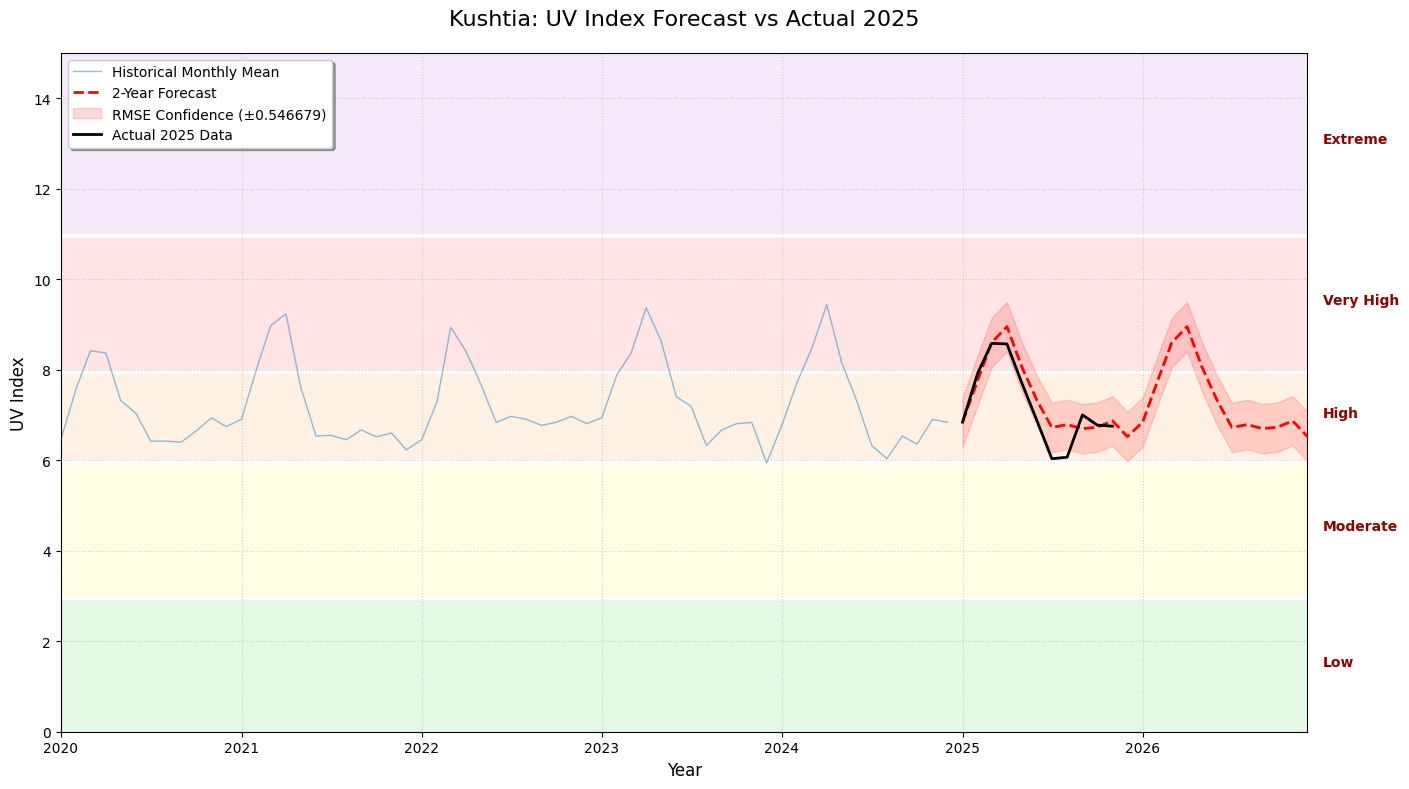

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load and Prepare Historical Data ---
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')
df = df_district.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Resample to Monthly Mean
df_monthly = df.set_index('date')['UV'].resample('MS').mean().reset_index()

# --- 2. Engineering Fourier Features for Seasonality ---
def add_fourier_features(df, period=12, n_terms=3):
    df = df.copy()
    for n in range(1, n_terms + 1):
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly)
df_features['year_val'] = df_features['date'].dt.year

# --- 3. Define Features and Target ---
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['UV']

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

lgb_model.fit(X_train, y_train)


# --- 5. Predict 2 Years Future (24 months) ---
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)
predictions_UV = lgb_model.predict(future_df[FEATURES])

# --- 6. Load and Prepare 2025 Validation Data ---
df_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])
# Resample 2025 data to monthly mean to match prediction frequency
df_2025_monthly = df_2025.set_index('date')['UV'].resample('MS').mean()

# --- 7. Integrated Visualization ---
fig, ax = plt.subplots(figsize=(14, 8))

# A. Historical Data
ax.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6', linewidth=1, alpha=0.5)

# B. Prediction Trend & Confidence Cloud (RMSE)
error_margin = 0.546679      # Your validated RMSE ##################################


ax.plot(future_dates, predictions_UV, label='2-Year Forecast', linestyle='--', color='red', linewidth=2, zorder=5)
ax.fill_between(future_dates, predictions_UV - error_margin, predictions_UV + error_margin, 
                color='red', alpha=0.15, label=f'RMSE Confidence (±{error_margin})', zorder=4)

# C. Actual 2025 Data (Validation)
ax.plot(df_2025_monthly.index, df_2025_monthly.values, label='Actual 2025 Data', 
        color='black', markersize=5, linewidth=2, zorder=6)

# D. WHO UV Category Bands
bands = [
    (0, 2.9, "Low", (0.0, 0.8, 0.0, 0.1)),
    (3, 5.9, "Moderate", (1.0, 1.0, 0.0, 0.1)),
    (6, 7.9, "High", (1.0, 0.5, 0.0, 0.1)),
    (8, 10.9, "Very High", (1.0, 0.0, 0.0, 0.1)),
    (11, 15, "Extreme", (0.6, 0.2, 0.8, 0.1))
]

for low, high, label, color in bands:
    ax.axhspan(low, high, facecolor=color, edgecolor=None, zorder=0)
    ax.text(future_dates[-1] + pd.DateOffset(months=1), (low + high) / 2, label, 
            fontsize=10, fontweight='bold', color="darkred")

# Formatting
ax.set_title(f'{district}: UV Index Forecast vs Actual 2025', fontsize=16, pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('UV Index', fontsize=12)
ax.set_ylim(0, 15)
ax.set_xlim(df_features['date'].min(), future_dates.max() + pd.DateOffset(months=3))
ax.legend(loc='upper left', frameon=True, facecolor='white', shadow=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.show()